In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np

from sandy.utils import CircularConduit
from sandy.utils import AnnularConduit

# Circular Conduit Representing Pipe Flow

In [2]:
D = 1
N = 1000
h = np.linspace(0,D,N)

Ac = np.zeros((N,))
Bc = np.zeros((N,))
Kc = np.zeros((N,))

for i in range(N):
    segment = CircularConduit(D,h[i]).upper
    Ac[i] = segment.area
    Bc[i] = segment.bound
    Kc[i] = segment.arc

csa = np.pi*D**2/4

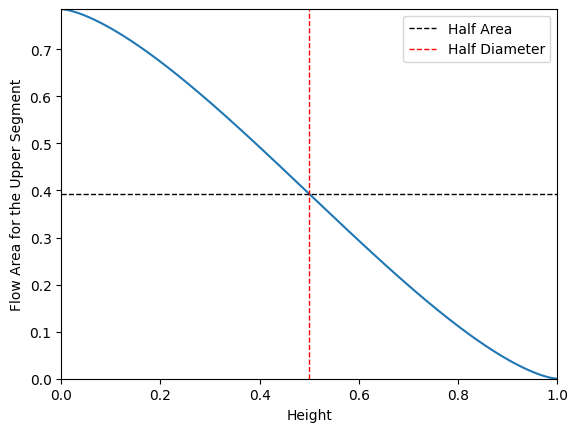

In [3]:
plt.plot(h,Ac)
plt.hlines(csa/2, 0, 1, colors = 'k', linestyles = '--', linewidth = 1, label="Half Area")
plt.vlines(D/2, 0, csa, colors = 'red', linestyle = '--', linewidth = 1, label="Half Diameter")
plt.xlabel("Height")
plt.ylabel("Flow Area for the Upper Segment")
plt.xlim(left=0,right=D)
plt.ylim(bottom=0,top=csa)
plt.legend()
plt.show()

# Annular Conduit Representing Annulus Flow

In [4]:
Do = 1
Di = 0.5

Aa = np.zeros((N,))
Ba = np.zeros((N,))
Ka = np.zeros((N,))

for i in range(N):
    segment = AnnularConduit(Do,Di,h[i]).upper
    Aa[i] = segment.area
    Ba[i] = segment.bound
    Ka[i] = segment.arc

csa_annular = np.pi*(Do**2-Di**2)/4

# Flow Area Comparison

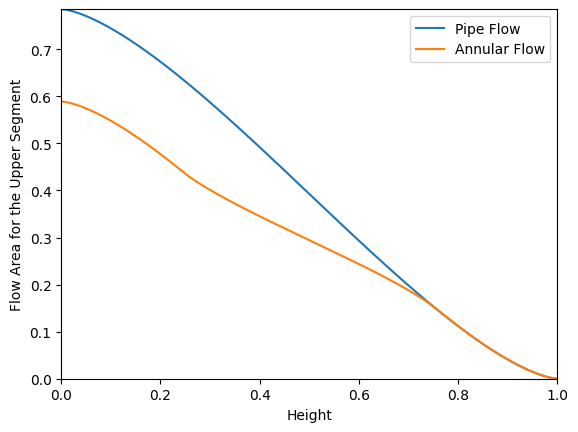

In [5]:
plt.plot(h,Ac,label="Pipe Flow")
plt.plot(h,Aa,label="Annular Flow")
# plt.hlines(csa/2, 0, 1, colors = 'k', linestyles = '--', linewidth = 1, label="Half Area")
# plt.vlines(D/2, 0, csa, colors = 'red', linestyle = '--', linewidth = 1, label="Half Diameter")
plt.xlabel("Height")
plt.ylabel("Flow Area for the Upper Segment")
plt.xlim(left=0,right=D)
plt.ylim(bottom=0,top=csa)
plt.legend()
plt.show()

# Bound Length Comparison

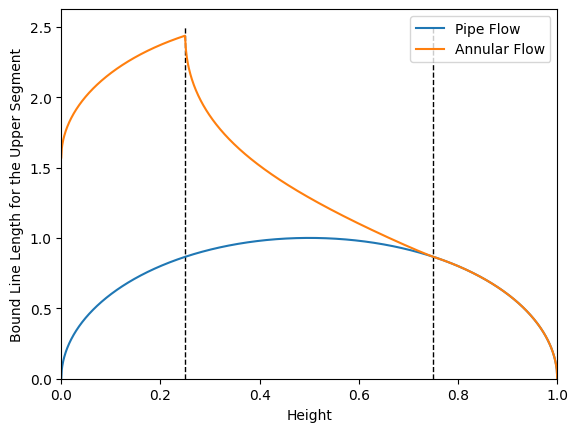

In [15]:
plt.vlines((Do-Di)/2,0,2.5,colors='k',linewidth=1,linestyle='--')
plt.vlines((Do+Di)/2,0,2.5,colors='k',linewidth=1,linestyle='--')
plt.plot(h,Bc,label="Pipe Flow")
plt.plot(h,Ba,label="Annular Flow")
plt.xlabel("Height")
plt.ylabel("Bound Line Length for the Upper Segment")
plt.xlim(left=0,right=Do)
plt.ylim(bottom=0)
plt.legend()
plt.show()

In [14]:
np.pi*Di

1.5707963267948966

In [13]:
diff = Ba-Bc; diff[:10]

array([1.57079633, 1.57079633, 1.57079633, 1.57079633, 1.57079633,
       1.57079633, 1.57079633, 1.57079633, 1.57079633, 1.57079633])

# Arc Length Comparison

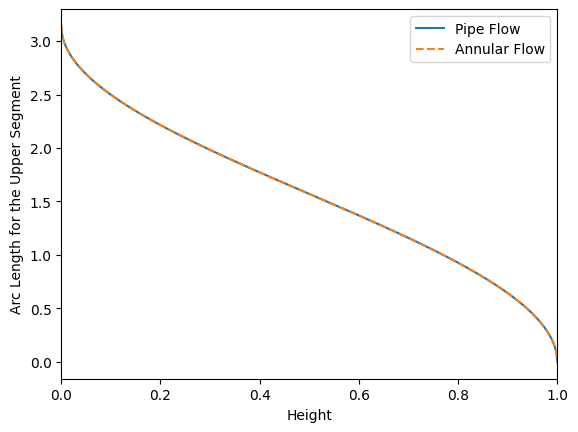

In [7]:
plt.plot(h,Kc,'-',label="Pipe Flow")
plt.plot(h,Ka,'--',label="Annular Flow")
plt.xlabel("Height")
plt.ylabel("Arc Length for the Upper Segment")
plt.xlim(left=0,right=D)
plt.legend()
plt.show()

# Schematic Representation of Annular Flow

In [8]:
def draw_annular_conduit_cross_section(ax, Router, Rinner, h, chord):

    upper_patch = patches.Circle((0, 0), Router, facecolor='mediumseagreen', edgecolor='none')
    ax.add_patch(upper_patch)
    upper_clip = patches.Rectangle((-Router, -Router + h), 2*Router, 2*Router - h, transform=ax.transData)
    upper_patch.set_clip_path(upper_clip)

    lower_patch = patches.Circle((0, 0), Router, facecolor='goldenrod', hatch='...', edgecolor='k')
    ax.add_patch(lower_patch)
    lower_clip = patches.Rectangle((-Router, -Router), 2*Router, h, transform=ax.transData)
    lower_patch.set_clip_path(lower_clip)

    outline_patch = patches.Circle((0, 0), Router, facecolor='none', edgecolor='k')
    ax.add_patch(outline_patch)

    ax.hlines(-Router + h, -chord/2, chord/2, colors='k', linewidth=1, zorder=1)
    
    inner_pipe = patches.Circle((0, 0), Rinner, facecolor='gray', hatch='\\\\\\', edgecolor='k', zorder=3)
    ax.add_patch(inner_pipe)

    ax.set_aspect('equal')
    ax.set_xlim(-Router * 1.1, Router * 1.1)
    ax.set_ylim(-Router * 1.1, Router * 1.1)

    ax.margins(0)

    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_yticks([])
    ax.set_yticklabels([])

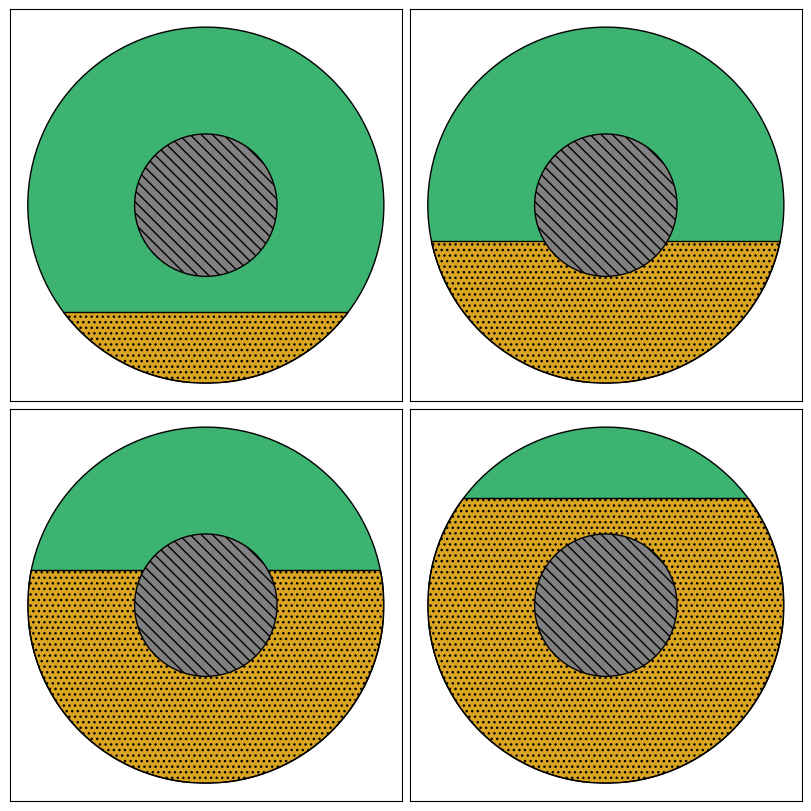

In [9]:
D = 10

c1 = CircularConduit(D,2)
c2 = CircularConduit(D,4)
c3 = CircularConduit(D,6)
c4 = CircularConduit(D,8)

fig = plt.figure(figsize=(8,8), layout='constrained')
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.)

ax1 = fig.add_subplot(gs[0, 0]) # Top row spanning all columns
ax2 = fig.add_subplot(gs[0, 1]) # Bottom left
ax3 = fig.add_subplot(gs[1, 0]) # Bottom left
ax4 = fig.add_subplot(gs[1, 1]) # Bottom left

draw_annular_conduit_cross_section(ax1,D/2,2,2,c1.bound())
draw_annular_conduit_cross_section(ax2,D/2,2,4,c2.bound())
draw_annular_conduit_cross_section(ax3,D/2,2,6,c3.bound())
draw_annular_conduit_cross_section(ax4,D/2,2,8,c4.bound())

gs.tight_layout(fig, pad=0, w_pad=0, h_pad=0)

plt.show()